In [60]:
#all imports here
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

### Loading data

In [61]:
def download_intraday_data(ticker: str, interval: str = "1m", period: str = "5d"):
    """
    Download intraday OHLCV data for a stock using yfinance.
    
    Args:
        ticker (str): Ticker symbol (e.g., 'AAPL').
        interval (str): Data interval ('1m', '5m', '15m', '1h', etc.)
        period (str): How much data to get ('1d', '5d', '1mo', etc.)
        
    Returns:
        pd.DataFrame: OHLCV dataframe.
    """
    df = yf.download(
        tickers=ticker,
        period=period,
        interval=interval,
        progress=False
    )
    # Flatten MultiIndex columns
    df.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df.columns.values]

    df = df.reset_index()
    return df

def plot_price(df: pd.DataFrame, ticker: str):
    """
    Plot Close price.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(df['Datetime'], df['Close'], label=f'{ticker} Close Price')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.title(f'{ticker} Intraday Close Price')
    plt.legend()
    plt.show()


In [62]:
df.shape

(1941, 19)

### Compute True VMAP

In [63]:
def compute_vwap(df: pd.DataFrame) -> pd.DataFrame:
    
    """
    Add VWAP column to intraday OHLCV DataFrame.
    Groups by each trading day.

    Args:
        df (pd.DataFrame): Must have ['Datetime', 'High', 'Low', 'Close', 'Volume']

    Returns:
        pd.DataFrame: Original DataFrame with 'VWAP' column added.
    """
    
     # Make sure datetime is datetime
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df['Date'] = df['Datetime'].dt.date
    
    # Typical Price = (H + L + C) / 3
    df['TP'] = (df['High_AAPL'] + df['Low_AAPL'] + df['Close_AAPL']) / 3
    df['TPV'] = df['TP'] * df['Volume_AAPL']


    # Check what columns you have first
    print(df.columns)

    # Compute cumulative sums within each day
    #df['TPV'] = df['TP'] * df['Volume']

    df['Cumulative_TPV'] = df.groupby('Date')['TPV'].cumsum()
    df['Cumulative_Volume'] = df.groupby('Date')['Volume_AAPL'].cumsum()

    df['VWAP'] = df['Cumulative_TPV'] / df['Cumulative_Volume']

    return df

def plot_vwap_vs_close(df: pd.DataFrame, ticker: str):
    """
    Plot Close price vs VWAP to see how well you're executing.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(df['Datetime'], df['Close_AAPL'], label='Close Price')
    plt.plot(df['Datetime'], df['VWAP'], label='VWAP', linestyle='--')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.title(f'{ticker}: Close vs VWAP')
    plt.legend()
    plt.show()



/var/folders/8j/2bschcy91hl2lzf_yf5v4gb00000gn/T/ipykernel_22863/2428254768.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(


                   Datetime  Close_AAPL   High_AAPL    Low_AAPL   Open_AAPL  \
0 2025-07-14 13:30:00+00:00  210.520004  210.679993  209.899994  209.908997   
1 2025-07-14 13:31:00+00:00  210.759995  210.880005  210.259995  210.419998   
2 2025-07-14 13:32:00+00:00  210.369995  210.910004  210.300003  210.759995   
3 2025-07-14 13:33:00+00:00  209.899994  210.360001  209.774994  210.340103   
4 2025-07-14 13:34:00+00:00  209.710007  209.910004  209.565002  209.899994   

   Volume_AAPL  
0      1519958  
1       273826  
2       174726  
3       194162  
4       200944  
Index(['Datetime', 'Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL',
       'Volume_AAPL', 'Date', 'TP', 'TPV'],
      dtype='object')
                    Datetime  Close_AAPL        VWAP
0  2025-07-14 13:30:00+00:00  210.520004  210.366664
1  2025-07-14 13:31:00+00:00  210.759995  210.407371
2  2025-07-14 13:32:00+00:00  210.369995  210.417960
3  2025-07-14 13:33:00+00:00  209.899994  210.381483
4  2025-07-14 13:34:0

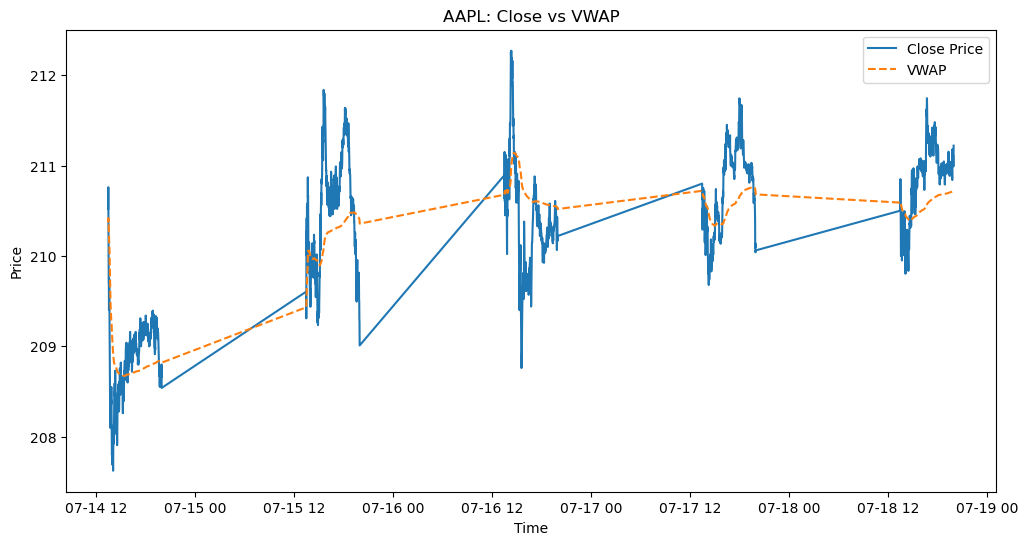

In [64]:
if __name__ == "__main__":
    ticker = "AAPL"
    df = download_intraday_data(ticker, interval="1m", period="5d")
    print(df.head())
    df = compute_vwap(df)
    #plot_price(df, ticker)
    print(df[['Datetime', 'Close_AAPL', 'VWAP']].head(20))
    plot_vwap_vs_close(df, ticker)

#### Naive Slicer implementation 

In [70]:
def plot_execution_vs_vwap(df: pd.DataFrame, ticker: str):
    """
    Plot your cumulative execution vs VWAP.
    """
    # Only rows where you actually bought
    df_fills = df[df['Shares_Bought'] > 0].copy()

    # Compute cumulative fill cost & avg execution price so far
    df_fills['Cumulative_Shares'] = df_fills['Shares_Bought'].cumsum()
    df_fills['Cumulative_Cost'] = df_fills['Fill_Cost'].cumsum()
    df_fills['Avg_Execution'] = df_fills['Cumulative_Cost'] / df_fills['Cumulative_Shares']

    plt.figure(figsize=(12, 6))
    plt.plot(df['Datetime'], df['Close_AAPL'], label='Close Price', alpha=0.5)
    plt.plot(df['Datetime'], df['VWAP'], label='True VWAP', linestyle='--', color='black')
    plt.plot(df_fills['Datetime'], df_fills['Avg_Execution'], label='Your Avg Execution', linestyle='-', color='red')

    plt.title(f"{ticker}: VWAP vs Execution vs Close")
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    



In [65]:
def baseline_slicer(df: pd.DataFrame, total_shares: int):
    """
    Simulate naive equal-time slicing.
    
    Args:
        df (pd.DataFrame): Must have ['Datetime', 'Close_AAPL', 'VWAP']
        total_shares (int): Total shares to buy.
        
    Returns:
        pd.DataFrame: DataFrame with 'Shares_Bought' and 'Fill_Cost' per slice.
    """
    slices = len(df)
    shares_per_slice = total_shares // slices
    
    df['Shares_Bought'] = shares_per_slice
    
    # If not divisible, buy remaining in first slice
    leftover = total_shares - shares_per_slice * slices
    df.at[0, 'Shares_Bought'] += leftover
    
    # Assume fill at Close price
    df['Fill_Cost'] = df['Shares_Bought'] * df['Close_AAPL']
    
    return df

def compute_execution_stats(df: pd.DataFrame):
    """
    Compute effective execution price and compare to true VWAP.
    """
    total_shares_filled = df['Shares_Bought'].sum()
    total_cost = df['Fill_Cost'].sum()
    
    avg_execution_price = total_cost / total_shares_filled
    
    true_vwap = df['VWAP'].iloc[-1]  # end-of-day VWAP
    
    print(f"Total Shares Filled: {total_shares_filled}")
    print(f"Average Execution Price: {avg_execution_price:.4f}")
    print(f"True VWAP: {true_vwap:.4f}")
    print(f"Slippage (bps): {(avg_execution_price - true_vwap) / true_vwap * 10_000:.2f} bps")


Total Shares Filled: 10000
Average Execution Price: 210.2819
True VWAP: 210.7426
Slippage (bps): -21.86 bps


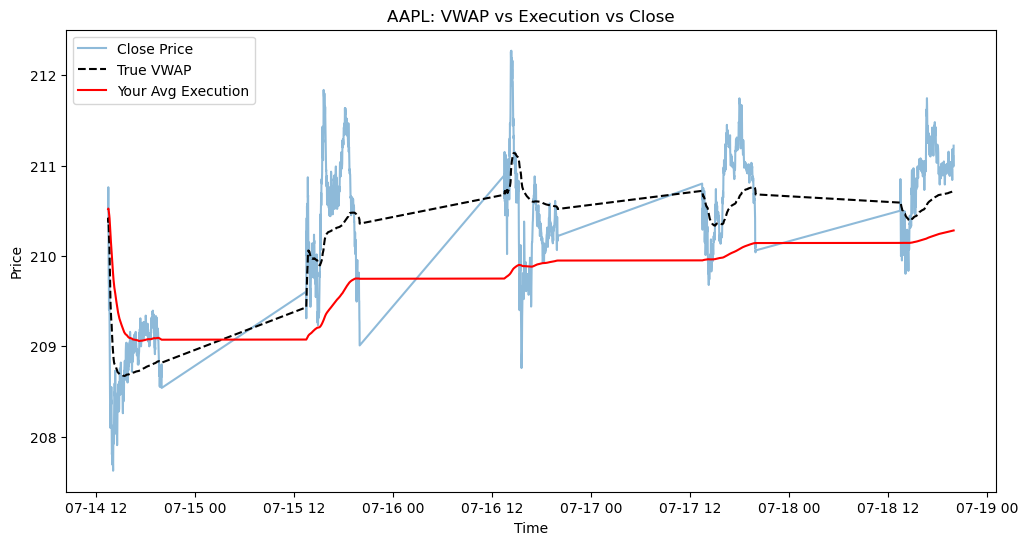

In [66]:
if __name__ == "__main__":
    
    df = baseline_slicer(df, total_shares=10_000)
    compute_execution_stats(df)
    plot_execution_vs_vwap(df, ticker)


#### Smart Silcing based on volume

In [67]:
def smart_slicer(df: pd.DataFrame, total_shares: int):
    """
    Proportional VWAP execution:
    - Base: % of daily market volume
    - Urgency: boost if price drifts up
    - Adaptive: boost or slow down if ahead/behind schedule
    """
    df = df.copy()

    # 1) Total market volume
    total_volume = df['Volume_AAPL'].sum()

    # 2) % of daily market volume for each slice
    df['Volume_Share'] = df['Volume_AAPL'] / total_volume

    # 3) Rolling drift signal for urgency (5-bar drift)
    df['Price_Drift'] = df['Close_AAPL'].diff().rolling(5).sum().fillna(0)

    # 4) Cumulative market vol share for adaptive tracking
    df['Cumulative_Market_Vol'] = df['Volume_AAPL'].cumsum()
    df['Market_Vol_Share'] = df['Cumulative_Market_Vol'] / total_volume

    # 5) Prepare output
    shares_list = []
    order_progress = 0.0  # % of total order done so far

    for idx, row in df.iterrows():
        # --- Base shares ---
        base_shares = row['Volume_Share'] * total_shares

        # --- Urgency boost if drift is positive ---
        urgency = 1.0
        if row['Price_Drift'] > 0:
            urgency = 1.2  # uptrend → buy more now

        # --- Adaptive boost/slow based on schedule ---
        schedule_diff = row['Market_Vol_Share'] - order_progress
        if schedule_diff > 0.02:
            boost = 1.2  # we are behind → catch up
        elif schedule_diff < -0.02:
            boost = 0.8  # we are ahead → slow down
        else:
            boost = 1.0

        # --- Final adjusted shares ---
        adjusted_shares = base_shares * urgency * boost

        shares_list.append(adjusted_shares)

        # --- Update progress ---
        order_progress += adjusted_shares / total_shares

    # Attach back
    df['Shares_Bought'] = pd.Series(shares_list).round().astype(int)

    # Fix rounding to match total order size exactly
    diff = total_shares - df['Shares_Bought'].sum()
    if diff != 0:
        df.at[0, 'Shares_Bought'] += diff

    return df

def add_impact_and_fill(df: pd.DataFrame, k_bps_per_pct: float = 0.5):
    """
    Simulate fill price with temporary price impact.
    """
    daily_volume = df['Volume_AAPL'].sum()

    fill_prices = []
    for _, row in df.iterrows():
        shares = row['Shares_Bought']
        interval_volume = row['Volume_AAPL']

        if interval_volume == 0:
            continue  # no fill possible

        pct = shares / interval_volume * 100  # %
        impact_bps = k_bps_per_pct * pct
        impact_multiplier = 1 + impact_bps / 10_000  # bps → decimal

        # Assume fill at Close plus impact
        fill_price = row['Close_AAPL'] * impact_multiplier
        fill_prices.append(fill_price)

    df = df.copy()
    df = df.loc[df['Shares_Bought'] > 0].copy()
    df['Fill_Price'] = fill_prices
    df['Fill_Cost'] = df['Shares_Bought'] * df['Fill_Price']

    return df
def compute_execution_stats_v2(df: pd.DataFrame):
    total_shares_filled = df['Shares_Bought'].sum()
    total_cost = df['Fill_Cost'].sum()

    avg_execution_price = total_cost / total_shares_filled
    true_vwap = df['VWAP'].iloc[-1]

    print(f"Total Shares Filled: {total_shares_filled}")
    print(f"Average Execution Price: {avg_execution_price:.4f}")
    print(f"True VWAP: {true_vwap:.4f}")
    print(f"Slippage (bps): {(avg_execution_price - true_vwap) / true_vwap * 10_000:.2f} bps")


In [68]:
def add_realistic_fill(df: pd.DataFrame, k_bps_per_pct: float = 0.5, spread_bps: float = 5):
    """
    Improved fill price model:
    - Fill price = mid ± spread/2
    - Passive: hit bid if liquidity is good
    - Aggressive: cross ask if liquidity is poor
    - Adds simple market impact bump
    """
    df = df.copy()
    daily_volume = df['Volume_AAPL'].sum()
    fill_prices = []

    for idx, row in df.iterrows():
        shares = row['Shares_Bought']
        interval_volume = row['Volume_AAPL']

        # Skip if no trade
        if shares == 0 or interval_volume == 0:
            fill_prices.append(np.nan)
            continue

        # --- Mid-price ---
        mid = (row['High_AAPL'] + row['Low_AAPL']) / 2

        # --- Spread ---
        spread = mid * spread_bps / 10_000  # convert bps → price

        # --- Passive or aggressive ---
        # If enough liquidity, try passive at bid; else cross ask
        liquidity_threshold = 0.002  # e.g. 0.2% of daily volume
        if interval_volume > daily_volume * liquidity_threshold:
            # Passive: get filled at bid
            fill_price = mid - 0.5 * spread
        else:
            # Aggressive: cross ask
            fill_price = mid + 0.5 * spread

        # --- Add simple market impact ---
        pct_interval = shares / interval_volume * 100  # percent of interval vol
        impact_bps = k_bps_per_pct * pct_interval

        fill_price *= 1 + (impact_bps / 10_000)

        fill_prices.append(fill_price)

    df['Fill_Price'] = fill_prices
    df['Fill_Cost'] = df['Fill_Price'] * df['Shares_Bought']

    return df



How it works
Volume share: same as before → anchor.

Urgency: uptrend? Buy more now.

Adaptive: check if you’re ahead/behind schedule.

If your cumulative % of order is lagging market flow → boost.

If you’re ahead → ease off.

Total Shares Filled: 10000
Average Execution Price: 210.2845
True VWAP: 210.7426
Slippage (bps): -21.73 bps


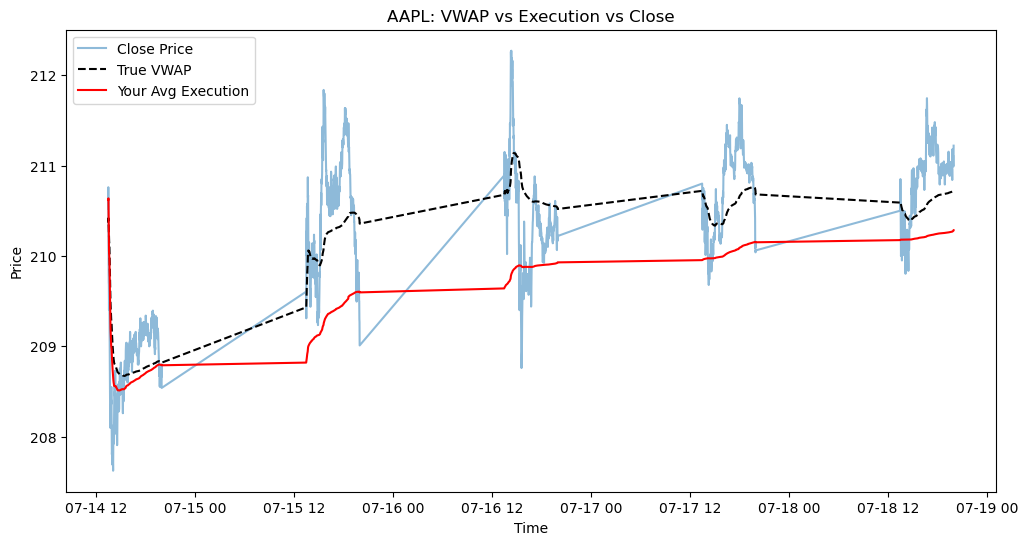

In [69]:
if __name__ == "__main__":
    
    df = smart_slicer(df, total_shares=10_000)
    df = add_realistic_fill(df, k_bps_per_pct=0.5, spread_bps=5)
    compute_execution_stats_v2(df)
    plot_execution_vs_vwap(df, ticker="AAPL")

#### Stress testing

In [72]:
for k_bps in [0.1, 10.5, 20.0]:
    df = smart_slicer(df, total_shares=10_000)
    df = add_realistic_fill(df, k_bps_per_pct=0.5, spread_bps=5)
    print(f"\nImpact factor: {k_bps} bps per % of interval vol")
    compute_execution_stats_v2(df)



Impact factor: 0.1 bps per % of interval vol
Total Shares Filled: 10000
Average Execution Price: 210.2845
True VWAP: 210.7426
Slippage (bps): -21.73 bps

Impact factor: 10.5 bps per % of interval vol
Total Shares Filled: 10000
Average Execution Price: 210.2845
True VWAP: 210.7426
Slippage (bps): -21.73 bps

Impact factor: 20.0 bps per % of interval vol
Total Shares Filled: 10000
Average Execution Price: 210.2845
True VWAP: 210.7426
Slippage (bps): -21.73 bps
